In [ ]:
# 1. Data import or Collection
from google.colab import files
import pandas as pd

# Step 1: Upload the file
uploaded = files.upload()

Saving Car-mpg.csv to Car-mpg (1).csv


In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.decomposition import PCA
from scipy.stats import zscore

# Read the dataset

mpg_df = pd.read_csv("Car-mpg.csv")

# drop the car name column as it is useless for the model
car_name = mpg_df['car_name']
mpg_df = mpg_df.drop('car_name', axis=1)
mpg_df.head()

In [ ]:
# horsepower is an object type though it is supposed to be numeric. Check if all the rows in this column are digits

temp = pd.DataFrame(mpg_df.hp.astype(str).str.isdigit())  # if the string is made of digits store True else False  in the hp column
temp[temp['hp'] == False]   # from temp take only those rows where hp has false

# On inspecting records number 32, 126 etc, we find "?" in the columns. Replace them with "nan"
#Replace them with nan and remove the records from the data frame that have "nan"
mpg_df = mpg_df.replace('?', np.nan)

# Convert the 'hp' column to numeric, coercing errors to NaN
mpg_df['hp'] = pd.to_numeric(mpg_df['hp'], errors='coerce')

# Fill NaN values with the median of the 'hp' column
mpg_df['hp'] = mpg_df['hp'].fillna(mpg_df['hp'].median())

# converting the hp column from object / string type to float
mpg_df['hp'] = mpg_df['hp'].astype('float64')

In [ ]:
# Split the wine data into separate training (70%) and test (30%) sets and then standardize it to unit variance:


X = mpg_df[mpg_df.columns[1:-1]]
y = mpg_df["mpg"]



In [ ]:
#Visually inspect the covariance between independent dimensions and between mpg and independent dimensions

sns.pairplot(mpg_df, diag_kind='kde')

In [ ]:
# We transform (centralize) the entire X (independent variable data) to zscores through transformation. We will create the PCA dimensions
# on this distribution.
sc = StandardScaler()
X_std =  sc.fit_transform(X)
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)


In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

In [ ]:
# Step 3 (continued): Sort eigenvalues in descending order

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

In [ ]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each
# eigen vector... there will be 8 entries as there are 8 eigen vectors)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 8 entries with 8 th entry
# cumulative reaching almost 100%




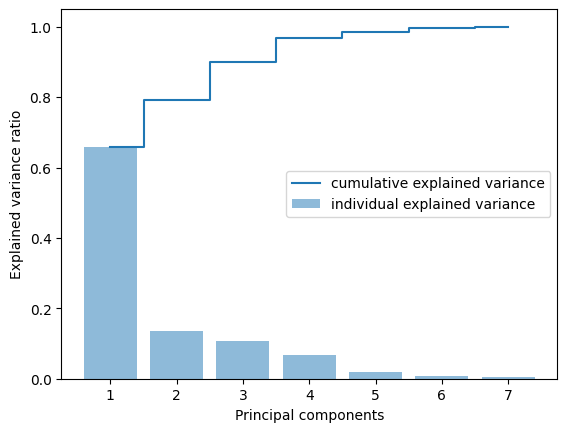

In [ ]:
plt.bar(range(1,8), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,8),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

In [ ]:
# P_reduce represents reduced mathematical space....

P_reduce = np.array(eigvectors_sorted[0:4])   # Reducing from 8 to 4 dimension space

X_std_4D = np.dot(X_std,P_reduce.T)   # projecting original data into principal component dimensions

Proj_data_df = pd.DataFrame(X_std_4D)  # converting array to dataframe for pairplot

In [ ]:
from sklearn import model_selection

test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = model_selection.train_test_split(Proj_data_df, y, test_size=test_size, random_state=seed)

In [ ]:
#Let us check it visually


sns.pairplot(Proj_data_df, diag_kind='kde')

In [ ]:
# Let us build a linear regression model on the PCA dimensions

# Import Linear Regression machine learning library
from sklearn.linear_model import LinearRegression

regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

regression_model.coef_

In [ ]:
regression_model.intercept_

In [ ]:
regression_model.score(X_test, y_test)

In [ ]:
# The model is performing poorly compared to the performance in original dimensions!
# Try the linear model with reduce PCA dimensions
# Why do you think the peformance has gone down? Isn't PCA supposed to increase the predictive power?

In [ ]:
# OBSERVATIONS -

# 1. There is a significant correlation between target (mpg) and first PCA (pc0)
# 2. Correlation between other PCA dimensions and mpg is very low
# 3. What was clearly visible as separate gaussians in original dimension is not visible any more. This is due to the fact that
#    PCA dimesions are composite of the original dimensions

# Lessons -

# 1. Uses PCA only when the original dimensions have linear relations. The original dimensions had negative curvilinear relations
# 2. Remove outliers before doing PCA. We have significant outliers which are due to mix up of the gaussians in original dimension

# Suggestion -

# 1. Segment the original data based on observations using K Means clustering
# 2. Remove the outliers from the segments
# 2. If the original dimensions show strong linear relations in the segments, then apply PCA